# Longitudinal analysis: two questions

**Q1. Do LH-intact and RH-intact patients differ, and does the difference matter?**
Side typicality is the direct test: does an intact hemisphere still read as the
side it is?

**Q2. Are symmetrically represented or lateralized categories more susceptible
after pediatric resection?** In adults the lateralized categories are the
vulnerable ones. The prediction for pediatric resection is open. The
hypothesis under test: symmetric categories reorganize more because the two
hemispheres are collaborative rather than redundant, so losing one forces
compensation, while lateralized categories can relocate more intact.

## Statistical framework

Primary is the per-patient control bootstrap, not a group permutation.
With 3 and 2 patients per group, a pooled group mean is driven by single
subjects, so each patient is evaluated individually against the control
distribution (10,000 iterations). Three tests:

1. **Per patient vs control CI** — each patient checked individually.
2. **Within-patient symmetric minus asymmetric** — paired across the five
   patients. This is the Q2 test.
3. **Difference of differences** — the patient symmetric-asymmetric gap against
   the control gap, bootstrapped.

Group permutation tests are reported alongside for reference, not as primary.

## Cohort

| group | n | subjects |
|---|---|---|
| LH-intact (right resection) | 3 | sub-004, sub-008, sub-079 |
| RH-intact (left resection) | 2 | sub-010, sub-021 |
| controls | 8 | two sessions each |
| nonOTC | 9 | **visual comparison only, never entered into a test** |

sub-079 is surgery right / intact left, confirmed in both `sub_info.csv` and
`patient_id_key.csv`. Earlier notes listing it as intact-right were wrong.

sub-108 session 2 is held out: its HighLevel z range is +/-48 against +/-6 to
15 in every other patient, from single-run inputs that are themselves normal.

## Measures

| # | measure | source |
|---|---|---|
| 1 | Peak location, 2D distance from fixed control mean | manuscript para 58 |
| 2 | Peak selectivity, max z in search mask | para 60 |
| 3 | Selective voxel count, z > 2.33, sqrt | para 62 |
| 4 | Mean between-category similarity, 7 mm sphere | para 67 |
| 5 | Between-category similarity, six pairs | para 67 |
| 6 | Geometry preservation, T1-to-T2 RDM correlation | longitudinal only |
| 7 | Side typicality and consistency, whole OTC | para 70-71, per session |

The laterality index and gradient tests are not included. The gradient is too
sensitive to interpret at this n.

ComBat is not applied; the harmonized files carry one session per subject.

In [1]:
import sys, warnings, importlib.util
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from pathlib import Path
warnings.filterwarnings('ignore')

GIT  = Path('/user_data/csimmon2/git_repos/sym_pt')
PROC = Path('/user_data/csimmon2/sym_pt')
D_LIU= GIT/'D_liu'
sys.path.insert(0,str(GIT))
from params import processed_dir

UNIVAR = D_LIU/'univariate_v1.csv'
RSA    = D_LIU/'rsa_v1.csv'
PEAKMNI= Path(processed_dir)/'group_results'/'peak_coords'/'peak_coords_mni.csv'
SUBINFO= GIT/'sub_info.csv'
FIGDIR = GIT/'C_results'/'figures'/'longitudinal_q12'; FIGDIR.mkdir(parents=True,exist_ok=True)
OUT    = D_LIU/'longitudinal_q12_results.csv'

EXCLUDE=['sub-017','sub-091','sub-095','sub-096','sub-027','sub-084']
EXCLUDE_SES=[('sub-108',2)]
ROIS=['face_FFA','house_PPA_strict','object_LOC','word_VWFA']
LAB={'face_FFA':'FFA','house_PPA_strict':'PPA','object_LOC':'LOC','word_VWFA':'VWFA'}
OWN={'face_FFA':'face','house_PPA_strict':'house','object_LOC':'object','word_VWFA':'word'}
ASYM=['face_FFA','word_VWFA']; SYM=['house_PPA_strict','object_LOC']
CATS=['face','house','object','word']
PAIRS=['face-house','face-object','face-word','house-object','house-word','object-word']
N_BOOT=10000; N_PERM=10000
RNG=np.random.RandomState(42)
COL={'control':'#7A7A7A','LH-intact':'#7398AF','RH-intact':'#EE7183','nonOTC':'#FF9800'}
print('asymmetric:',[LAB[r] for r in ASYM],'| symmetric:',[LAB[r] for r in SYM])

asymmetric: ['FFA', 'VWFA'] | symmetric: ['PPA', 'LOC']


In [2]:
# ── load, build change scores ───────────────────────────────────────────────
def age_table():
    si=pd.read_csv(SUBINFO); si['subject_id']=si['sub'].astype(str)
    si['ses_num']=pd.to_numeric(si['ses'].astype(str).str.extract(r'(\d+)',expand=False),
                                errors='coerce').astype('Int64')
    return si[['subject_id','ses_num','age']].dropna().drop_duplicates(['subject_id','ses_num'])

def load(p):
    d=pd.read_csv(p); d=d[~d.subject_id.isin(EXCLUDE)].copy()
    d['ses_num']=pd.to_numeric(d['session'],errors='coerce').astype('Int64')
    for s,x in EXCLUDE_SES: d=d[~((d.subject_id==s)&(d.ses_num==x))]
    d=d.drop(columns=[c for c in ('age',) if c in d.columns])
    return d.merge(age_table(),on=['subject_id','ses_num'],how='left')

def label(r):
    if r['status']=='control': return 'control'
    if r['group']=='nonOTC':   return 'nonOTC'
    return 'LH-intact' if r['intact_hemi']=='left' else 'RH-intact'

def own_hemi(df):
    c=df[df.status=='control']; p=df[df.status!='control']
    p=p[((p.intact_hemi=='left')&(p.hemi=='l'))|((p.intact_hemi=='right')&(p.hemi=='r'))]
    return pd.concat([c,p],ignore_index=True)

def change(df,val,keys=('subject_id','hemi','category'),sqrt=False):
    keys=list(keys); out=[]
    for k,g in df.groupby(keys,dropna=True):
        g=g.drop_duplicates('ses_num').sort_values('ses_num')
        if len(g)<2: continue
        a,b=g.iloc[0],g.iloc[-1]
        if pd.isna(a[val]) or pd.isna(b[val]): continue
        va,vb=float(a[val]),float(b[val])
        if sqrt: va,vb=np.sqrt(max(va,0)),np.sqrt(max(vb,0))
        rec=dict(zip(keys,k if isinstance(k,tuple) else (k,)))
        rec.update(v_first=va,v_last=vb,delta=vb-va,group=a['group'],status=a['status'],
                   intact_hemi=a['intact_hemi'],
                   age=float(b['age']) if not pd.isna(b['age']) else np.nan,
                   interval=(float(b['age']-a['age']) if not pd.isna(a['age']) else np.nan))
        rec['grp']=label(rec); out.append(rec)
    return own_hemi(pd.DataFrame(out))

uni=load(UNIVAR); rsa=load(RSA)
uni_u=uni.drop_duplicates(['subject_id','ses_num','hemi','category'])
rsa_u=rsa.drop_duplicates(['subject_id','ses_num','hemi','category'])
btw_u=rsa.drop_duplicates(['subject_id','ses_num','hemi','category','pair'])

CH={}
CH['peak_selectivity']=change(uni_u,'peak_z')
CH['voxel_count_sqrt']=change(uni_u,'volume',sqrt=True)
mb=(btw_u[btw_u.pair.isin(PAIRS)]
    .groupby(['subject_id','ses_num','hemi','category','status','group','intact_hemi','age'],
             as_index=False).fisher_r.mean())
CH['mean_between']=change(mb,'fisher_r')
CH['between_pairs']=change(btw_u,'fisher_r',keys=('subject_id','hemi','category','pair'))

# peak location: fixed control reference
if PEAKMNI.exists():
    mni=load(PEAKMNI)
    cf=(mni[mni.status=='control'].sort_values('ses_num')
        .groupby(['subject_id','hemi','category']).head(1))
    CEN={}
    for (h,roi),g in cf.groupby(['hemi','category']):
        v=g[['peak_x_mni','peak_y_mni']].dropna().values
        if len(v)>=3: CEN[(h,roi)]=v.mean(0)
    rows=[]
    for (s,h,roi),g in mni.groupby(['subject_id','hemi','category']):
        if (h,roi) not in CEN: continue
        g=g.drop_duplicates('ses_num').sort_values('ses_num')
        if len(g)<2: continue
        a,b=g.iloc[0],g.iloc[-1]
        pa=a[['peak_x_mni','peak_y_mni']].astype(float).values
        pb=b[['peak_x_mni','peak_y_mni']].astype(float).values
        if np.isnan(pa).any() or np.isnan(pb).any(): continue
        cen=CEN[(h,roi)]
        rec=dict(subject_id=s,hemi=h,category=roi,
                 v_first=float(np.linalg.norm(pa-cen)),v_last=float(np.linalg.norm(pb-cen)),
                 group=a['group'],status=a['status'],intact_hemi=a['intact_hemi'],
                 age=float(b['age']) if not pd.isna(b['age']) else np.nan)
        rec['delta']=rec['v_last']-rec['v_first']; rec['grp']=label(rec); rows.append(rec)
    CH['peak_location']=own_hemi(pd.DataFrame(rows))
else:
    print('MISSING',PEAKMNI); CH['peak_location']=pd.DataFrame()

for k,v in CH.items(): print(f'{k:20s} rows {len(v):5d} subjects {v.subject_id.nunique() if len(v) else 0:3d}')

peak_selectivity     rows   360 subjects  22
voxel_count_sqrt     rows   360 subjects  22
mean_between         rows   231 subjects  13
between_pairs        rows  1386 subjects  13
peak_location        rows   360 subjects  22


## Measure 6. Geometry preservation

The correlation between a subject's six between-category similarities at the
first session and the same six at the last, within each ROI. Higher means the
representational structure is more preserved. This is the measure with a prior
result (February 2026) and the only one with no cross-sectional counterpart.

In [3]:
def geometry(df):
    out=[]
    for (s,h,roi),g in df.groupby(['subject_id','hemi','category']):
        piv=g.pivot_table(index='ses_num',columns='pair',values='fisher_r').reindex(columns=PAIRS)
        ss=sorted(piv.index)
        if len(ss)<2: continue
        a,b=piv.loc[ss[0]].values,piv.loc[ss[-1]].values
        if np.isnan(a).any() or np.isnan(b).any(): continue
        meta=g.iloc[0]
        rec=dict(subject_id=s,hemi=h,category=roi,delta=float(pearsonr(a,b)[0]),
                 group=meta['group'],status=meta['status'],intact_hemi=meta['intact_hemi'],
                 age=float(meta['age']) if not pd.isna(meta['age']) else np.nan)
        rec['grp']=label(rec); out.append(rec)
    return own_hemi(pd.DataFrame(out))

CH['geometry']=geometry(rsa)
g=CH['geometry']
print('geometry rows',len(g),'| subjects',g.subject_id.nunique())
print()
print('Per-patient geometry preservation, this run:')
pt=g[g.status!='control']
print(pt[pt.category.isin(ROIS)].pivot_table(index=['grp','subject_id'],
      columns='category',values='delta').rename(columns=LAB).round(3).to_string())

FEB={'sub-004':dict(FFA=0.75,VWFA=0.75,PPA=0.83,LOC=0.60),
     'sub-008':dict(FFA=0.12,VWFA=0.12,PPA=-0.08,LOC=-0.08),
     'sub-010':dict(FFA=0.81,VWFA=0.81,PPA=0.04,LOC=0.04),
     'sub-021':dict(FFA=0.92,VWFA=0.92,PPA=0.41,LOC=0.41),
     'sub-079':dict(FFA=0.76,VWFA=0.76,PPA=0.60,LOC=0.60)}
print()
print('February figure read off geo_preserve_asym-sym (approximate, for direction only):')
print(pd.DataFrame(FEB).T.round(2).to_string())
print()
print('February reported: symmetric < asymmetric in 5/5, paired t(4)=4.378, p=.012.')
print('Computed on Desikan-Killiany parcels at 75th percentile, not these 7 mm spheres.')

geometry rows 231 | subjects 13

Per-patient geometry preservation, this run:
category                FFA    PPA    LOC   VWFA
grp       subject_id                            
LH-intact sub-004     0.854  0.533  0.447  0.286
          sub-008     0.054 -0.485 -0.616  0.062
          sub-079     0.760  0.617 -0.601  0.747
RH-intact sub-010    -0.198 -0.433  0.253  0.324
          sub-021     0.981  0.276  0.408  0.857

February figure read off geo_preserve_asym-sym (approximate, for direction only):
          FFA  VWFA   PPA   LOC
sub-004  0.75  0.75  0.83  0.60
sub-008  0.12  0.12 -0.08 -0.08
sub-010  0.81  0.81  0.04  0.04
sub-021  0.92  0.92  0.41  0.41
sub-079  0.76  0.76  0.60  0.60

February reported: symmetric < asymmetric in 5/5, paired t(4)=4.378, p=.012.
Computed on Desikan-Killiany parcels at 75th percentile, not these 7 mm spheres.


## Measure 7. Side typicality and consistency, per session

Follows `H_RosenkeRSM/otc_rsm_rosenke.py`: the four category-versus-all-others
maps (copes 6 to 9) over the whole OTC mask, correlated across categories
within subject, giving six off-diagonal values per hemisphere per session.

Side typicality is the correlation with same-side control hemispheres minus the
correlation with opposite-side ones, so a uniform drop in similarity to all
controls subtracts out. Consistency is each subject's mean correlation with
others in their own group. Both are computed per session and differenced.

Deliberately unharmonized, as in the source script: ComBat adjusts each
category map separately, which would distort a correlation across categories.

In [4]:
# ── Rosenke per session. Functions inlined from
#    D_liu/verified/02_tfce_analyses_dontuse_useharmony.py so the module is not
#    imported: it uses the walrus operator and will not parse on Python 3.7.
ROSENKE_OK = True
try:
    import nibabel as nib
    from nilearn import datasets as nl_datasets
    from nilearn.image import resample_to_img
except ImportError as e:
    ROSENKE_OK = False
    print('nibabel/nilearn unavailable:', e)

COPES_OTHERS = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
RPAIRS = [(a, b) for i, a in enumerate(CATS) for b in CATS[i+1:]]
PC = [f'{a}-{b}' for a, b in RPAIRS]

VOTC_LABEL_NAMES = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

def build_otc_masks(outdir):
    at = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
    img = at.maps if isinstance(at.maps, nib.Nifti1Image) else nib.load(at.maps)
    data = img.get_fdata(); labels = at.labels
    full = np.zeros(data.shape, dtype=bool)
    for name in VOTC_LABEL_NAMES:
        hit = [i for i, l in enumerate(labels) if name in l]
        if hit: full |= (data == hit[0])
    mid = data.shape[0] // 2
    out = {}
    outdir.mkdir(parents=True, exist_ok=True)
    for hemi, slc in [('l', slice(mid, None)), ('r', slice(None, mid))]:
        m = full.copy(); m[slc] = False
        pth = outdir / f'votc_{hemi}_mask.nii.gz'
        nib.save(nib.Nifti1Image(m.astype(np.uint8), img.affine), pth)
        out[hemi] = pth
        print(f'  {hemi}: {int(m.sum())} voxels -> {pth.name}')
    return out

def zstat_path(sid, session, first_session, cope):
    feat = (Path(processed_dir)/sid/f'ses-{session}'/'derivatives'/'fsl'/'loc'
            /'HighLevel.gfeat'/f'cope{cope}.feat'/'stats')
    return (feat/'zstat1_mni.nii.gz' if session == first_session
            else feat/f'zstat1_ses{first_session}_mni.nii.gz')

def od_for(sid, session, first_session, mask_path):
    paths = [zstat_path(sid, session, first_session, COPES_OTHERS[c]) for c in CATS]
    if not all(Path(p).exists() for p in paths): return None
    img0 = nib.load(str(paths[0]))
    m = resample_to_img(nib.load(str(mask_path)), img0,
                        interpolation='nearest').get_fdata() > 0.5
    X = np.vstack([nib.load(str(p)).get_fdata()[m] for p in paths])
    good = np.isfinite(X).all(0); X = X[:, good]
    if X.shape[1] < 50 or (X.std(axis=1) == 0).any(): return None
    rsm = np.arctanh(np.clip(np.corrcoef(X), -0.999, 0.999))
    idx = {c: i for i, c in enumerate(CATS)}
    return np.array([rsm[idx[a], idx[b]] for a, b in RPAIRS])

rsm_long = pd.DataFrame()
if ROSENKE_OK:
    masks = build_otc_masks(Path(processed_dir)/'group_results'/'otc_rsm_long')
    si2 = pd.read_csv(SUBINFO); si2['subject_id'] = si2['sub'].astype(str)
    si2['ses_num'] = pd.to_numeric(
        si2['ses'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce').astype(int)
    si2 = si2[~si2.subject_id.isin(EXCLUDE)]
    for s_, x_ in EXCLUDE_SES: si2 = si2[~((si2.subject_id == s_) & (si2.ses_num == x_))]
    nses = si2.groupby('subject_id').ses_num.nunique()
    si2 = si2[si2.subject_id.isin(nses[nses >= 2].index)]

    recs, missing = [], []
    for sid, g in si2.groupby('subject_id'):
        g = g.sort_values('ses_num'); first = int(g.ses_num.iloc[0]); meta = g.iloc[0]
        hemis = (['l','r'] if meta['group'] == 'control'
                 else (['l'] if meta['intact_hemi'] == 'left' else ['r']))
        for _, r in g.iterrows():
            for h in hemis:
                e = od_for(sid, int(r.ses_num), first, masks[h])
                if e is None:
                    missing.append((sid, int(r.ses_num), h)); continue
                recs.append(dict(subject_id=sid, ses_num=int(r.ses_num), hemi=h,
                                 group=meta['group'],
                                 status=('control' if meta['group'] == 'control' else 'patient'),
                                 intact_hemi=meta['intact_hemi'], age=float(r['age']),
                                 **{k: val for k, val in zip(PC, e)}))
    rsm_long = pd.DataFrame(recs)
    rsm_long.to_csv(D_LIU/'otc_rsm_persession.csv', index=False)
    print('per-session whole-OTC rows:', len(rsm_long),
          '| subjects:', rsm_long.subject_id.nunique() if len(rsm_long) else 0)
    if missing:
        print('no usable maps for', len(missing), 'subject x session x hemi cells:')
        for mm in missing[:12]: print('  ', mm)

/home/csimmon2/anaconda3/envs/brainiak_env/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


  l: 11340 voxels -> votc_l_mask.nii.gz
  r: 11540 voxels -> votc_r_mask.nii.gz
per-session whole-OTC rows: 0 | subjects: 0
no usable maps for 68 subject x session x hemi cells:
   ('sub-004', 1, 'l')
   ('sub-004', 2, 'l')
   ('sub-004', 3, 'l')
   ('sub-004', 5, 'l')
   ('sub-004', 6, 'l')
   ('sub-007', 1, 'r')
   ('sub-007', 3, 'r')
   ('sub-007', 4, 'r')
   ('sub-008', 1, 'l')
   ('sub-008', 2, 'l')
   ('sub-010', 2, 'r')
   ('sub-010', 3, 'r')


In [5]:
if ROSENKE_OK and len(rsm_long):
    ref=(rsm_long[rsm_long.status=='control'].sort_values('ses_num')
         .groupby(['subject_id','hemi']).head(1))
    Lref=ref[ref.hemi=='l']; Rref=ref[ref.hemi=='r']

    def mean_r(vec,refdf,exclude):
        rs=[pearsonr(vec,o[PC].values.astype(float))[0]
            for _,o in refdf.iterrows() if o.subject_id!=exclude]
        return float(np.mean(rs)) if rs else np.nan

    rows=[]
    for _,r in rsm_long.iterrows():
        v=r[PC].values.astype(float)
        same=mean_r(v,Lref if r.hemi=='l' else Rref,r.subject_id)
        opp =mean_r(v,Rref if r.hemi=='l' else Lref,r.subject_id)
        own = rsm_long[(rsm_long.group==r.group)&(rsm_long.ses_num==r.ses_num)]
        cons=mean_r(v,own,r.subject_id)
        rows.append(dict(subject_id=r.subject_id,ses_num=r.ses_num,hemi=r.hemi,
                         group=r.group,status=r.status,intact_hemi=r.intact_hemi,
                         age=r.age,typicality=same-opp,consistency=cons))
    tp=pd.DataFrame(rows); tp['category']='wholeOTC'
    CH['side_typicality']=change(tp,'typicality')
    CH['consistency']=change(tp,'consistency')
    for k in ['side_typicality','consistency']:
        print(f'{k:18s} rows {len(CH[k]):4d} subjects {CH[k].subject_id.nunique()}')
    print()
    print(CH['side_typicality'][['subject_id','grp','v_first','v_last','delta']]
          .round(3).to_string(index=False))
else:
    print('side typicality and consistency not computed')

side typicality and consistency not computed


## The three tests

1. Each patient against the control bootstrap CI, individually.
2. Within-patient symmetric minus asymmetric, paired across patients.
3. Difference of differences: the patient gap against the control gap.

In [6]:
results=[]
def rec(**kw):
    base=dict(question=None,measure=None,test=None,group=None,subject=None,level=None,
              value=np.nan,ctrl_mean=np.nan,ci_lo=np.nan,ci_hi=np.nan,outside_ci=np.nan,
              diff=np.nan,d=np.nan,p=np.nan,n=np.nan,note='')
    base.update(kw); return base

def boot_ci(vals,n=N_BOOT,rng=RNG):
    v=np.asarray(vals,float); v=v[~np.isnan(v)]
    if len(v)<3: return np.nan,np.nan
    m=np.array([rng.choice(v,len(v),True).mean() for _ in range(n)])
    return float(np.percentile(m,2.5)),float(np.percentile(m,97.5))

def perm_paired(d,n=N_PERM,rng=RNG):
    d=np.asarray(d,float); d=d[~np.isnan(d)]
    if len(d)<2: return np.nan,np.nan,np.nan
    obs=d.mean(); null=np.array([(d*rng.choice([-1,1],len(d))).mean() for _ in range(n)])
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(n+1)
    return obs,p,(obs/d.std(ddof=1) if d.std(ddof=1)>0 else np.nan)

def perm_ind(a,b,n=N_PERM,rng=RNG):
    a,b=np.asarray(a,float),np.asarray(b,float); a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return np.nan,np.nan,np.nan
    obs=a.mean()-b.mean(); pool=np.r_[a,b]; na=len(a)
    null=np.array([ (lambda i: pool[i[:na]].mean()-pool[i[na:]].mean())(rng.permutation(len(pool)))
                    for _ in range(n)])
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(n+1)
    sp=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return obs,p,(obs/sp if sp>0 else np.nan)

def unibi(ch):
    s=ch[ch.category.isin(ROIS)].copy()
    s['kind']=np.where(s.category.isin(ASYM),'asym','sym')
    return s.groupby(['subject_id','grp','hemi','kind'],as_index=False).delta.mean()

SCALARS=[m for m in ['peak_location','peak_selectivity','voxel_count_sqrt',
                     'mean_between','geometry'] if m in CH and len(CH[m])]

# ── Test 1: each patient vs the control CI, per ROI ───────────────────────
for m in SCALARS:
    ch=CH[m]
    for roi in ROIS:
        for hemi in ['l','r']:
            cv=ch[(ch.grp=='control')&(ch.category==roi)&(ch.hemi==hemi)].delta.dropna().values
            if len(cv)<3: continue
            lo,hi=boot_ci(cv)
            side='LH-intact' if hemi=='l' else 'RH-intact'
            for g in [side,'nonOTC']:
                sub=ch[(ch.grp==g)&(ch.category==roi)&(ch.hemi==hemi)]
                for _,r in sub.iterrows():
                    results.append(rec(question='Q1/Q2',measure=m,test='patient_vs_ctrl_CI',
                        group=g,subject=r.subject_id,level=LAB[roi],value=r.delta,
                        ctrl_mean=float(np.nanmean(cv)),ci_lo=lo,ci_hi=hi,
                        outside_ci=int(r.delta<lo or r.delta>hi),n=len(cv),
                        note='visual only' if g=='nonOTC' else ''))

# ── Test 2 and 3: Q2, symmetric vs asymmetric ─────────────────────────────
for m in SCALARS:
    w=unibi(CH[m])
    pv=w.pivot_table(index=['subject_id','grp'],columns='kind',values='delta').dropna().reset_index()
    pv['gap']=pv['sym']-pv['asym']
    for g in ['control','LH-intact','RH-intact','nonOTC','patients_all']:
        sub=pv[pv.grp.isin(['LH-intact','RH-intact'])] if g=='patients_all' else pv[pv.grp==g]
        if len(sub)<2: continue
        obs,p,d=perm_paired(sub.gap.values)
        results.append(rec(question='Q2',measure=m,test='sym_minus_asym_within',
            group=g,level='paired across subjects',diff=obs,d=d,
            p=(np.nan if g=='nonOTC' else p),n=len(sub),
            note=('visual only' if g=='nonOTC' else
                  f"{int((sub.gap<0).sum())}/{len(sub)} negative")))
    # diff of diff
    ctrl=pv[pv.grp=='control'].gap.values
    for g in ['LH-intact','RH-intact','patients_all']:
        sub=pv[pv.grp.isin(['LH-intact','RH-intact'])] if g=='patients_all' else pv[pv.grp==g]
        if len(sub)<2 or len(ctrl)<3: continue
        obs,p,d=perm_ind(sub.gap.values,ctrl)
        results.append(rec(question='Q2',measure=m,test='diff_of_diff_vs_ctrl',
            group=g,level='gap vs control gap',diff=obs,d=d,p=p,
            ctrl_mean=float(np.nanmean(ctrl)),n=len(sub)))

# ── Q1: the two patient groups ────────────────────────────────────────────
for m in SCALARS:
    ch=CH[m]
    for roi in ROIS:
        a=ch[(ch.grp=='LH-intact')&(ch.category==roi)].delta.dropna().values
        b=ch[(ch.grp=='RH-intact')&(ch.category==roi)].delta.dropna().values
        if len(a)<2 or len(b)<2: continue
        obs,p,d=perm_ind(a,b)
        results.append(rec(question='Q1',measure=m,test='LH_vs_RH_intact',
            group='LH-intact vs RH-intact',level=LAB[roi],diff=obs,d=d,p=p,n=len(a)+len(b)))

# side typicality: Q1's direct test
for m in ['side_typicality','consistency']:
    if m not in CH or not len(CH[m]): continue
    ch=CH[m]
    cv=ch[ch.grp=='control'].delta.dropna().values
    lo,hi=boot_ci(cv)
    for g in ['LH-intact','RH-intact','nonOTC']:
        sub=ch[ch.grp==g]
        for _,r in sub.iterrows():
            results.append(rec(question='Q1',measure=m,test='patient_vs_ctrl_CI',
                group=g,subject=r.subject_id,level='wholeOTC',value=r.delta,
                ctrl_mean=float(np.nanmean(cv)) if len(cv) else np.nan,ci_lo=lo,ci_hi=hi,
                outside_ci=(int(r.delta<lo or r.delta>hi) if not np.isnan(lo) else np.nan),
                n=len(cv),note='visual only' if g=='nonOTC' else ''))
    a=ch[ch.grp=='LH-intact'].delta.dropna().values
    b=ch[ch.grp=='RH-intact'].delta.dropna().values
    if len(a)>=2 and len(b)>=2:
        obs,p,d=perm_ind(a,b)
        results.append(rec(question='Q1',measure=m,test='LH_vs_RH_intact',
            group='LH-intact vs RH-intact',level='wholeOTC',diff=obs,d=d,p=p,n=len(a)+len(b)))

res=pd.DataFrame(results); res.to_csv(OUT,index=False)
print('wrote',OUT,'|',len(res),'rows')

wrote /user_data/csimmon2/git_repos/sym_pt/D_liu/longitudinal_q12_results.csv | 266 rows


In [7]:
pd.set_option('display.width',220)
print('════ Q2  symmetric minus asymmetric, within patient ════')
q2=res[(res.question=='Q2')&(res.test=='sym_minus_asym_within')]
print(q2[['measure','group','diff','d','p','n','note']].round(3).to_string(index=False))
print()
print('════ Q2  difference of differences against controls ════')
dd=res[res.test=='diff_of_diff_vs_ctrl']
print(dd[['measure','group','diff','ctrl_mean','d','p','n']].round(3).to_string(index=False))
print()
print('════ Q1  LH-intact versus RH-intact ════')
q1=res[res.test=='LH_vs_RH_intact']
print(q1[['measure','level','diff','d','p','n']].round(3).to_string(index=False))
print()
print('════ patients outside the control CI ════')
oc=res[(res.test=='patient_vs_ctrl_CI')&(res.outside_ci==1)&(res.note!='visual only')]
print(oc[['measure','group','subject','level','value','ctrl_mean','ci_lo','ci_hi']]
      .round(3).to_string(index=False) if len(oc) else 'none')

════ Q2  symmetric minus asymmetric, within patient ════
         measure        group    diff      d     p  n         note
   peak_location      control  -1.463 -0.415 0.276  8 5/8 negative
   peak_location    LH-intact  -7.026 -0.907 0.503  3 2/3 negative
   peak_location    RH-intact  12.522  0.625 1.000  2 1/2 negative
   peak_location       nonOTC   0.441  0.110   NaN  9  visual only
   peak_location patients_all   0.793  0.051 0.873  5 3/5 negative
peak_selectivity      control  -0.215 -0.162 0.647  8 4/8 negative
peak_selectivity    LH-intact   0.377  0.349 0.749  3 1/3 negative
peak_selectivity    RH-intact  -0.799 -1.481 0.502  2 2/2 negative
peak_selectivity       nonOTC   0.036  0.017   NaN  9  visual only
peak_selectivity patients_all  -0.094 -0.091 0.875  5 3/5 negative
voxel_count_sqrt      control  -6.170 -0.301 0.403  8 5/8 negative
voxel_count_sqrt    LH-intact   0.682  0.032 1.000  3 1/3 negative
voxel_count_sqrt    RH-intact -14.163 -0.926 0.501  2 2/2 negative
voxel

## Figures

saved fig1


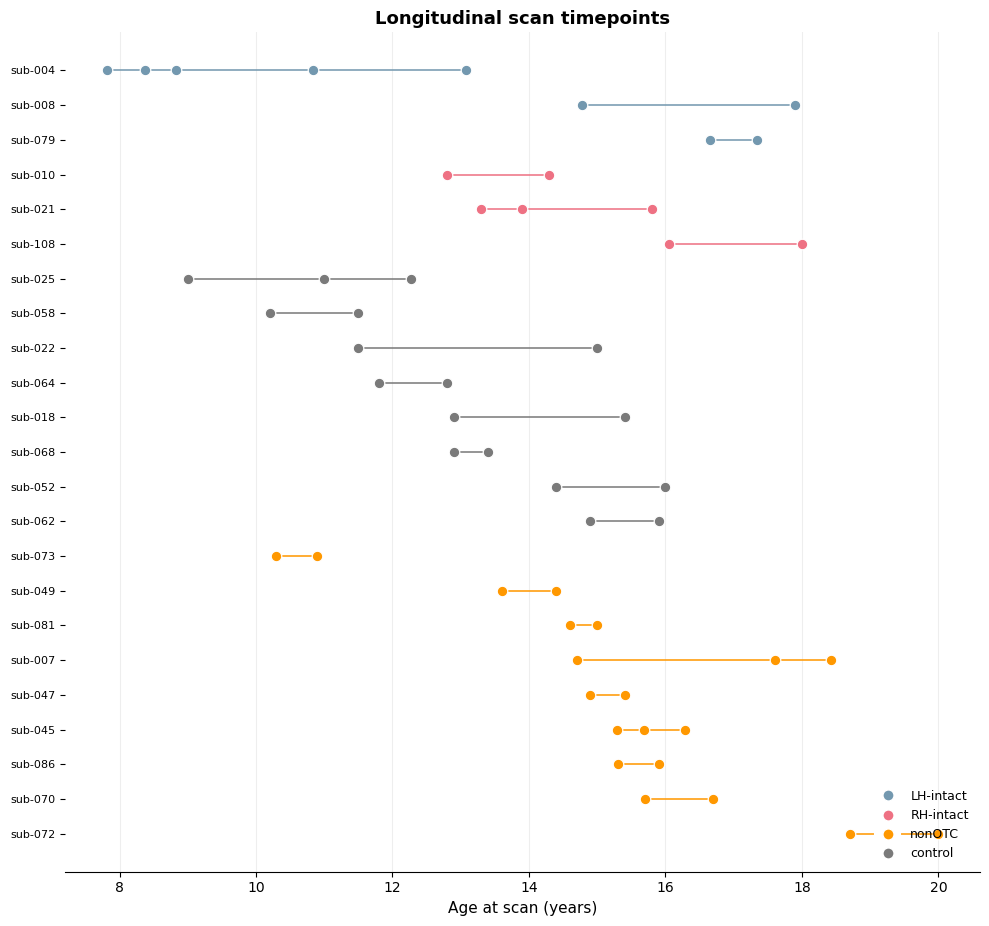

In [8]:
# ── Figure 1. Scan timeline, three groups ─────────────────────────────────
si=pd.read_csv(SUBINFO); si['subject_id']=si['sub'].astype(str)
si['ses_num']=pd.to_numeric(si['ses'].astype(str).str.extract(r'(\d+)',expand=False),
                            errors='coerce').astype(int)
si=si[~si.subject_id.isin(EXCLUDE)]
n=si.groupby('subject_id').ses_num.nunique(); si=si[si.subject_id.isin(n[n>=2].index)]
si['grp']=si.apply(lambda r: 'control' if r['group']=='control' else
                   ('nonOTC' if r['group']=='nonOTC' else
                    ('LH-intact' if r['intact_hemi']=='left' else 'RH-intact')),axis=1)
order=(si.groupby(['grp','subject_id']).age.min().reset_index()
       .sort_values(['grp','age'],ascending=[True,True]))
order['y']=range(len(order))
fig,ax=plt.subplots(figsize=(10,0.32*len(order)+2))
for _,o in order.iterrows():
    g=si[si.subject_id==o.subject_id].sort_values('age')
    ax.plot(g.age,[o.y]*len(g),'-',color=COL[o.grp],lw=1.4,zorder=2,alpha=.8)
    ax.scatter(g.age,[o.y]*len(g),s=58,color=COL[o.grp],edgecolor='white',lw=.9,zorder=3)
ax.set_yticks(order.y); ax.set_yticklabels(order.subject_id,fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('Age at scan (years)',fontsize=11)
ax.set_title('Longitudinal scan timepoints',fontsize=13,fontweight='bold')
ax.grid(axis='x',color='#EEEEEE',zorder=0)
for sp in ('top','right','left'): ax.spines[sp].set_visible(False)
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=COL[k],
          markersize=8,label=k) for k in ['LH-intact','RH-intact','nonOTC','control']],
          frameon=False,fontsize=9,loc='lower right')
fig.tight_layout(); fig.savefig(FIGDIR/'fig1_scan_timeline.png',dpi=200,bbox_inches='tight')
print('saved fig1')

saved fig2


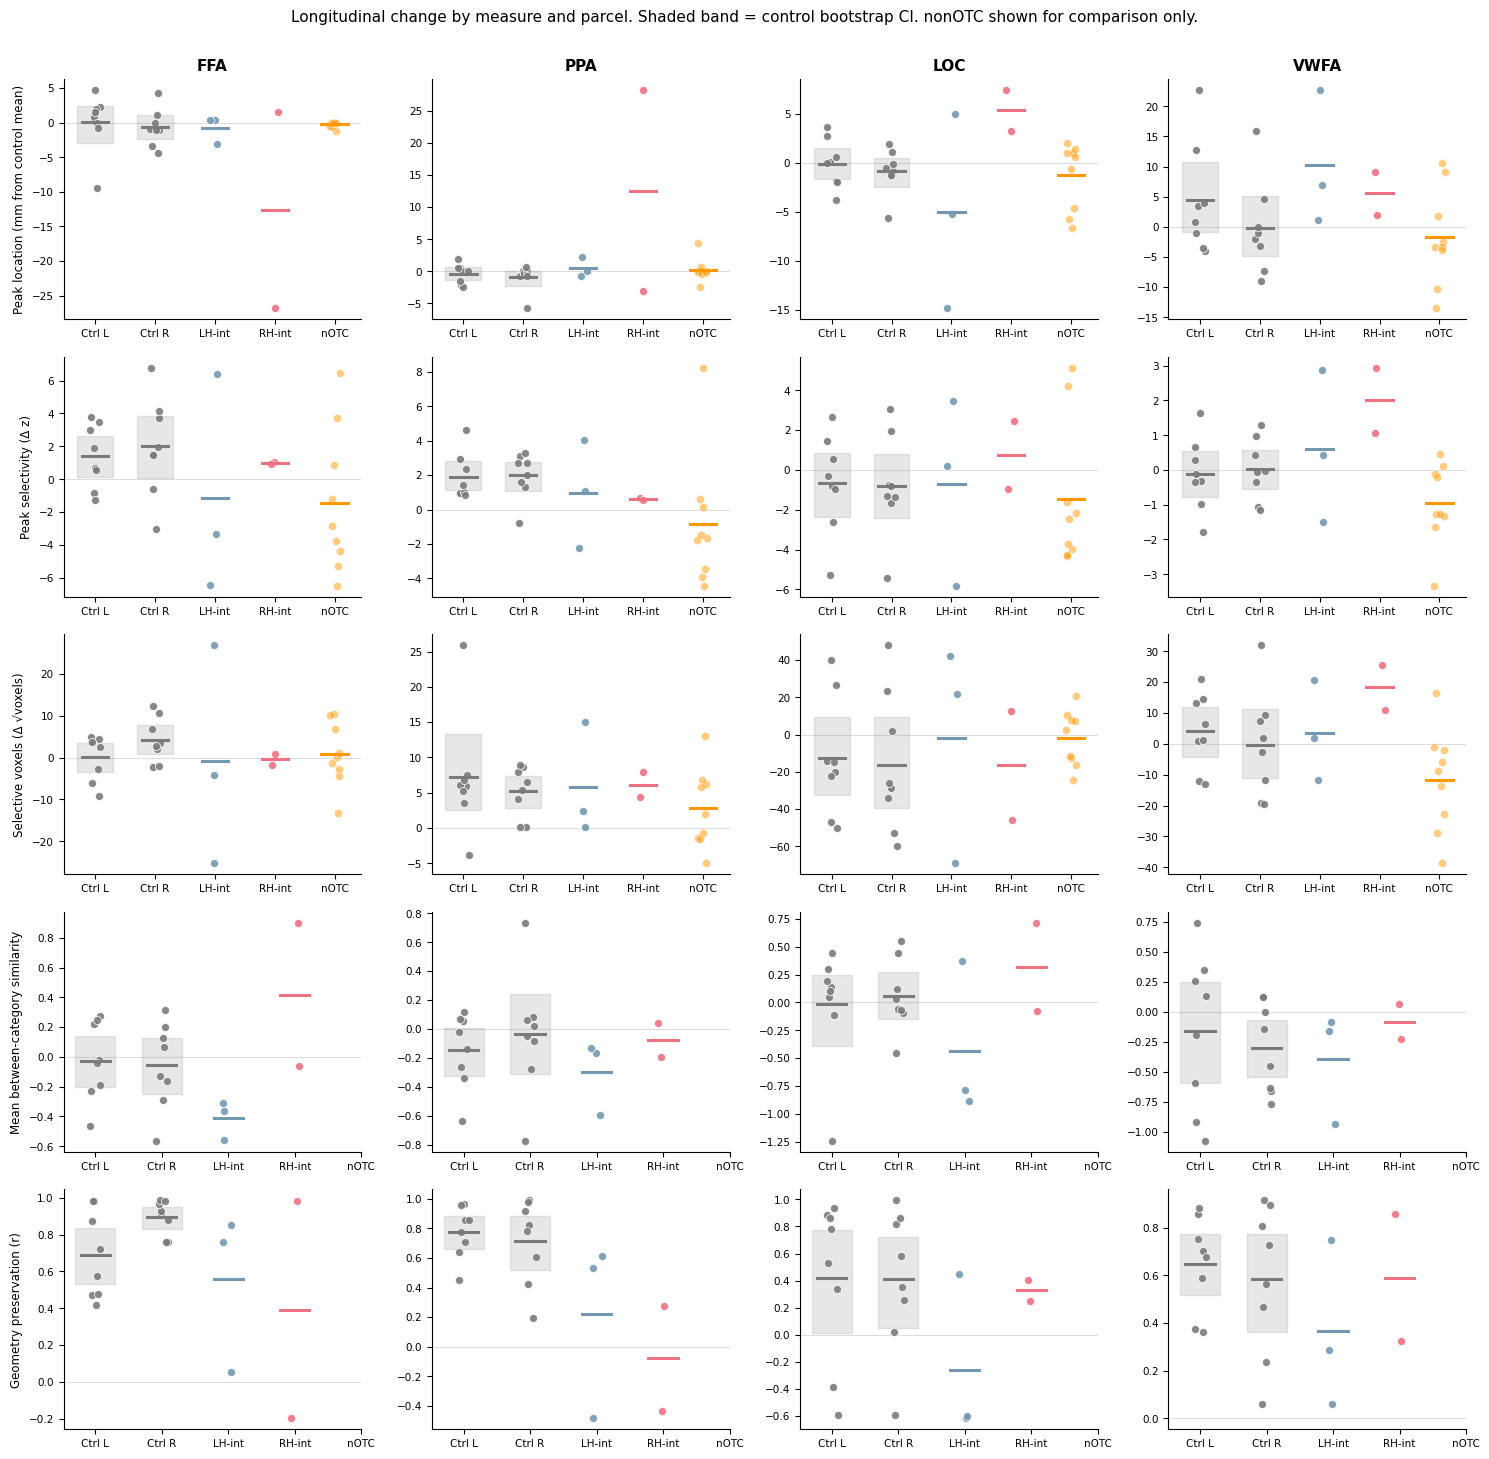

In [9]:
# ── Figure 2. Per-measure change, each patient against the control CI ─────
PLOT=[(m,t) for m,t in [('peak_location','Peak location (mm from control mean)'),
      ('peak_selectivity','Peak selectivity (\u0394 z)'),
      ('voxel_count_sqrt','Selective voxels (\u0394 \u221avoxels)'),
      ('mean_between','Mean between-category similarity'),
      ('geometry','Geometry preservation (r)')] if m in CH and len(CH[m])]
fig,axes=plt.subplots(len(PLOT),4,figsize=(15,2.9*len(PLOT)),squeeze=False)
for ri,(m,t) in enumerate(PLOT):
    ch=CH[m]
    for ci,roi in enumerate(ROIS):
        ax=axes[ri][ci]
        ax.axhline(0,color='#DDDDDD',lw=.8,zorder=0)
        for xi,(g,hemi) in enumerate([('control','l'),('control','r'),
                                      ('LH-intact','l'),('RH-intact','r'),('nonOTC',None)]):
            if g=='control':
                v=ch[(ch.grp=='control')&(ch.category==roi)&(ch.hemi==hemi)].delta.dropna().values
            elif g=='nonOTC':
                v=ch[(ch.grp=='nonOTC')&(ch.category==roi)].delta.dropna().values
            else:
                v=ch[(ch.grp==g)&(ch.category==roi)].delta.dropna().values
            if len(v)==0: continue
            col=COL[g]
            ax.scatter(np.full(len(v),xi)+RNG.uniform(-.09,.09,len(v)),v,s=34,
                       color=col,edgecolor='white',lw=.6,
                       alpha=(.5 if g=='nonOTC' else .9),zorder=3)
            if g=='control' and len(v)>=3:
                lo,hi=boot_ci(v)
                ax.add_patch(plt.Rectangle((xi-.3,lo),.6,hi-lo,color=col,alpha=.18,zorder=1))
            ax.plot([xi-.22,xi+.22],[v.mean()]*2,color=col,lw=2.2,zorder=4)
        ax.set_xticks(range(5))
        ax.set_xticklabels(['Ctrl L','Ctrl R','LH-int','RH-int','nOTC'],fontsize=7.5)
        if ci==0: ax.set_ylabel(t,fontsize=8.5)
        if ri==0: ax.set_title(LAB[roi],fontsize=11,fontweight='bold')
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
        ax.tick_params(labelsize=7.5)
fig.suptitle('Longitudinal change by measure and parcel. Shaded band = control bootstrap CI. '
             'nonOTC shown for comparison only.',fontsize=11,y=1.003)
fig.tight_layout(); fig.savefig(FIGDIR/'fig2_measures_by_parcel.png',dpi=200,bbox_inches='tight')
print('saved fig2')

saved fig3


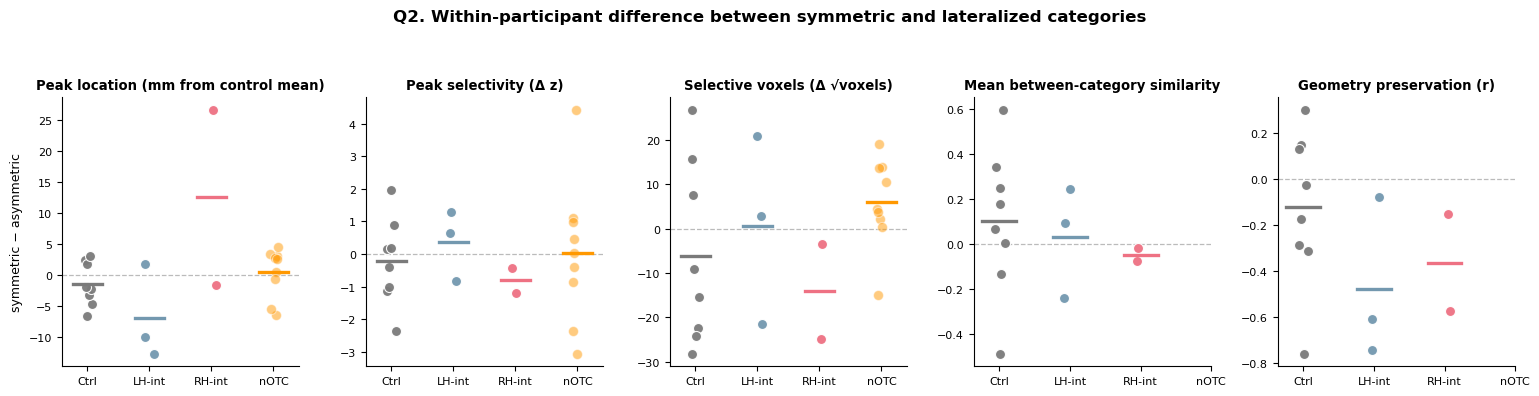

In [10]:
# ── Figure 3. Q2, symmetric minus asymmetric per subject ─────────────────
fig,axes=plt.subplots(1,len(PLOT),figsize=(3.1*len(PLOT),4),squeeze=False)
for ci,(m,t) in enumerate(PLOT):
    ax=axes[0][ci]; w=unibi(CH[m])
    pv=w.pivot_table(index=['subject_id','grp'],columns='kind',values='delta').dropna().reset_index()
    pv['gap']=pv['sym']-pv['asym']
    ax.axhline(0,color='#BBBBBB',lw=.9,ls='--',zorder=0)
    for xi,g in enumerate(['control','LH-intact','RH-intact','nonOTC']):
        v=pv[pv.grp==g].gap.values
        if len(v)==0: continue
        ax.scatter(np.full(len(v),xi)+RNG.uniform(-.08,.08,len(v)),v,s=52,color=COL[g],
                   edgecolor='white',lw=.8,alpha=(.5 if g=='nonOTC' else .95),zorder=3)
        ax.plot([xi-.24,xi+.24],[v.mean()]*2,color=COL[g],lw=2.4,zorder=4)
    ax.set_xticks(range(4)); ax.set_xticklabels(['Ctrl','LH-int','RH-int','nOTC'],fontsize=8)
    ax.set_title(t,fontsize=9.5,fontweight='bold')
    if ci==0: ax.set_ylabel('symmetric \u2212 asymmetric',fontsize=9)
    for sp in ('top','right'): ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8)
fig.suptitle('Q2. Within-participant difference between symmetric and lateralized categories',
             fontsize=12,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.92])
fig.savefig(FIGDIR/'fig3_sym_minus_asym.png',dpi=200,bbox_inches='tight')
print('saved fig3')

In [11]:
# ── Figure 4. Q1, side typicality ────────────────────────────────────────
if 'side_typicality' in CH and len(CH['side_typicality']):
    fig,axes=plt.subplots(1,2,figsize=(9,4))
    for ax,m,t in [(axes[0],'side_typicality','Side typicality'),
                   (axes[1],'consistency','Within-group consistency')]:
        ch=CH[m]; ax.axhline(0,color='#BBBBBB',lw=.9,ls='--',zorder=0)
        cv=ch[ch.grp=='control'].delta.dropna().values
        if len(cv)>=3:
            lo,hi=boot_ci(cv)
            ax.add_patch(plt.Rectangle((-.35,lo),.7,hi-lo,color=COL['control'],alpha=.18,zorder=1))
        for xi,g in enumerate(['control','LH-intact','RH-intact','nonOTC']):
            v=ch[ch.grp==g].delta.dropna().values
            if len(v)==0: continue
            ax.scatter(np.full(len(v),xi)+RNG.uniform(-.07,.07,len(v)),v,s=56,color=COL[g],
                       edgecolor='white',lw=.8,alpha=(.5 if g=='nonOTC' else .95),zorder=3)
            ax.plot([xi-.24,xi+.24],[v.mean()]*2,color=COL[g],lw=2.4,zorder=4)
        ax.set_xticks(range(4)); ax.set_xticklabels(['Ctrl','LH-int','RH-int','nOTC'],fontsize=9)
        ax.set_title(t,fontsize=11,fontweight='bold'); ax.set_ylabel('change, first to last',fontsize=9)
        for sp in ('top','right'): ax.spines[sp].set_visible(False)
    fig.suptitle('Q1. Whole-OTC arrangement over time',fontsize=12,fontweight='bold')
    fig.tight_layout(rect=[0,0,1,.92])
    fig.savefig(FIGDIR/'fig4_side_typicality.png',dpi=200,bbox_inches='tight')
    print('saved fig4')
else:
    print('fig4 skipped: side typicality not computed')
print()
print('figures in',FIGDIR)

fig4 skipped: side typicality not computed

figures in /user_data/csimmon2/git_repos/sym_pt/C_results/figures/longitudinal_q12


## Reading this

- **Q2** is answered by the symmetric-minus-asymmetric test and its
  difference-of-differences against controls. With five patients the direction
  and the count (how many of five fall the same way) carry more than the
  p-value.
- **Q1** is answered by side typicality, which asks whether an intact
  hemisphere still resembles same-side controls more than opposite-side ones,
  and by the LH-versus-RH contrasts per parcel.
- **nonOTC** appears in every figure and is labelled `visual only` in the
  results table. It is never entered into a statistical comparison.

## Outstanding

1. ComBat, if the longitudinal section is to be on the manuscript's scale.
2. sub-108 session 2, held out pending the higher-level fit.
3. Three controls (sub-038, sub-059, sub-067) have raw first sessions that have
   not been preprocessed. They would take the longitudinal control group from
   8 toward 11.
4. The February geometry values printed above were computed on Desikan-Killiany
   parcels, so they are a direction check, not a like-for-like comparison.